<a href="https://colab.research.google.com/github/Annette-1/Ecuaciones_Diferenciales_Parciales/blob/main/Tutorial_Sympy_y_network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <span style="color:blue;">**Tutorial Sympy y network**</span>
 <span style="color:purple;"></span>

 ## <span style="color:orange;"> **Sympy** biblioteca de Python para matemáticas simbólicas que permite resolver problemas de álgebra, cálculo y ecuaciones con precisión exacta.</span>

###Comandos basicos para resolver ecuaciones diferenciales en Simpy
<span style="color:purple;"> **Tema 1.Python**</span>
Para  resolver  con  SymPy  usamos  dsolve  con  la  sintaxis:
<span style="color:blue;">sympy.solvers.ode.dsolve(eq,func=None,hint'default’,simplify=True,ics=None,xi=None, eta=None,x0=0,n=6,**kwargs).</span>

importamos la librerías SymPy a Python

In [216]:
import sympy as sp
import numpy as exp

Definimos las variables independiente y dependiente ası como los parametros de forma simbolica

In [217]:
t=sp.symbols('t')
p=sp.Function('p')
a=sp.symbols('a')
b=sp.symbols('b')
p0=sp.symbols('p0')

Ahora definimos la ecuación diferencial con la condición inicial usando dsolve:

In [218]:
ode=sp.Eq(sp.Derivative(p(t),t)-a*p(t)+b*p(t)*p(t),0)
sol = sp.dsolve(ode,p(t),ics={p(0):p0})

Obteniendo así la solución:
<span style="color:blue;">Nota: poner sp.Eq("...") para q defina la función</span>

In [219]:
sp.Eq(p(t), a*sp.exp(a*(t+sp.log(b*p0/(-a+b*p0))/a))/(b*(sp.exp(a*(t+sp.log(b*p0/(-a + b*p0))/a)) - 1)))

Eq(p(t), a*exp(a*(t + log(b*p0/(-a + b*p0))/a))/(b*(exp(a*(t + log(b*p0/(-a + b*p0))/a)) - 1)))

Definimos a continuación los valores de a,b y p0, y evaluamos las respectivas soluciones (una para cada condición inicial):

In [220]:
constants={a:0.03,b:0.0001,p0:5}
sol1=sol.subs(constants)
constants={a:0.03,b:0.0001,p0:6}
sol2=sol.subs(constants)
constants={a:0.03,b:0.0001,p0:7}
sol3=sol.subs(constants)

La función lambdify permite definir una función a partir de la expresión simbolica:

In [221]:
func1 = sp.lambdify(t,sol1.rhs,'numpy')
func2 = sp.lambdify(t,sol2.rhs,'numpy')
func3 = sp.lambdify(t,sol3.rhs,'numpy')

<span style="color:purple;"> **Tema 2: Multiplicación  de matrices eigenvalores, eigenvectores y Diagonalización de matrices**</span>

se realiza principalmente utilizando el operador * entre dos objetos, (ej. C = A * B). La operación sigue las reglas del álgebra matricial: el número de columnas de la primera matriz debe coincidir con el de filas de la segunda.

In [222]:
import sympy as sp
from sympy import Matrix, symbols

Definimos las matrices

In [223]:
A = Matrix([[1, 2], [3, 4]])
B = Matrix([[5, 6], [7, 8]])
resultado = A * B

In [224]:
resultado

Matrix([
[19, 22],
[43, 50]])

 <span style="color:purple;">**Eigenvalores, Eigenvectores, y Diagonalizacion**</span>  returns a dictionary of eigenvalue: algebraic_multiplicity pairs (similar to the output of roots).
 Para encontrar los eigenvalores de una matriz, usamos la funcion $eigenvals$ esto nos retorna

In [225]:
M = Matrix([[3, -2,  4, -2], [5,  3, -3, -2], [5, -2,  2, -2], [5, -2, -3,  3]])

In [226]:
M

Matrix([
[3, -2,  4, -2],
[5,  3, -3, -2],
[5, -2,  2, -2],
[5, -2, -3,  3]])

In [227]:
M.eigenvals()

{3: 1, -2: 1, 5: 2}

Esto significa que M tiene valores propios -2, 3 y 5, y que los valores propios -2 y 3 tienen multiplicidad algebraica 1 y que el valor propio 5 tiene multiplicidad algebraica 2.

Para hallar los vectores propios de una matriz, utilice eigenvects. eigenvects devuelve una lista de tuplas con la forma (valor propio, multiplicidad_algebraica, [vectores propios]).

In [228]:
M.eigenvects()

[(-2,
  1,
  [Matrix([
   [0],
   [1],
   [1],
   [1]])]),
 (3,
  1,
  [Matrix([
   [1],
   [1],
   [1],
   [1]])]),
 (5,
  2,
  [Matrix([
   [1],
   [1],
   [1],
   [0]]),
   Matrix([
   [ 0],
   [-1],
   [ 0],
   [ 1]])])]

Para diagonalizar una matriz, utilice diagonalize. diagonalize devuelve una tupla, donde es diagonal y $M=PDP^{-1}$.

In [229]:
M = Matrix([[3, -2,  4, -2], [5,  3, -3, -2], [5, -2,  2, -2], [5, -2, -3,  3]])
P, D = M.diagonalize()

In [230]:
P

Matrix([
[0, 1, 1,  0],
[1, 1, 1, -1],
[1, 1, 1,  0],
[1, 1, 0,  1]])

In [231]:
D

Matrix([
[-2, 0, 0, 0],
[ 0, 3, 0, 0],
[ 0, 0, 5, 0],
[ 0, 0, 0, 5]])

In [232]:
P*D*P**-1
P*D*P**-1 == M #verifica la condición M=PDP^{-1}

True

**Operaciones Básicas con matrices**

Shape:
Para obtener la forma de una matriz, utilice la función shape().

In [233]:
from sympy import shape
L = Matrix([[1, 2, 3], [-2, 0, 4]])
L
shape(L)

(2, 3)

Para obtener una fila o columna individual de una matriz, use fila o columna. Por ejemplo, L.row(0) obtendrá la primera fila. L.col(-1) obtendrá la última columna.

In [234]:
L.row(0)

Matrix([[1, 2, 3]])

In [235]:
L.col(-1)

Matrix([
[3],
[4]])

**Eliminar e insertar filas y columnas**
Para eliminar una fila o columna, utilice row_del o col_del. Estas operaciones modificarán la matriz existente.

In [236]:
L.col_del(0)
L

Matrix([
[2, 3],
[0, 4]])

In [237]:
L.row_del(1)
L

Matrix([[2, 3]])

Para insertar filas o columnas, utilice **row_insert o col_insert**. Estas operaciones no se realizan en el mismo lugar.


In [238]:
L = L.row_insert(1, Matrix([[0, 4]]))
L

Matrix([
[2, 3],
[0, 4]])

In [239]:
L = L.col_insert(0, Matrix([1, -2]))
L

Matrix([
[ 1, 2, 3],
[-2, 0, 4]])

Multiplicación de matrices por vectores

In [240]:
# Crear una matriz 2x2
A = Matrix([[2, 3],
            [1, 4]])
A

Matrix([
[2, 3],
[1, 4]])

In [241]:
# Crear un vector columna 2x1
v = Matrix([1, 2])
v

Matrix([
[1],
[2]])

In [242]:
# Crear un vector fila 1x3
w = Matrix([[1, 2, 3]])
w

Matrix([[1, 2, 3]])

In [243]:
# Multiplicar matriz A por vector v (A * v)
resultado = A * v
print("A * v =")
resultado

A * v =


Matrix([
[8],
[9]])

In [244]:
# También puedes multiplicar si el vector es fila (con dimensiones adecuadas)
B = Matrix([[1, 2, 3],
            [4, 5, 6]])
w = Matrix([1, 1, 1])  # Vector columna
resultado2 = B * w
print("\nB * w =")
resultado2


B * w =


Matrix([
[ 6],
[15]])

Mltiplicacón usando símbolos (variables simbólicas)

In [245]:
# Definir símbolos
x, y, z = symbols('x y z')

# Matriz con símbolos
M_sym = Matrix([[x, y],
                [z, 1]])

# Vector con símbolos
v_sym = Matrix([2*x, y**2])

# Multiplicación
resultado_sym = M_sym * v_sym
print("Multiplicación con símbolos:")
resultado_sym

Multiplicación con símbolos:


Matrix([
[2*x**2 + y**3],
[ 2*x*z + y**2]])

Multiplicación matriz-vector
La multiplicación se realiza con el operador *:

In [246]:
# Multiplicar matriz A por vector v (A * v)
resultado = A * v
print("A * v =")
resultado

# También puedes multiplicar si el vector es fila (con dimensiones adecuadas)
B = Matrix([[1, 2, 3],
            [4, 5, 6]])
w = Matrix([1, 1, 1])  # Vector columna
resultado2 = B * w
print("\nB * w =")
resultado2

A * v =

B * w =


Matrix([
[ 6],
[15]])

**Vectores como objetos Row y Col**
SymPy permite crear vectores explícitamente como fila o columna:

In [247]:
# Vector columna (por defecto)
v_col = Matrix([1, 2, 3])
print("Vector columna (3x1):")
v_col

# Vector fila (1x3)
v_row = Matrix([[1, 2, 3]])
print("\nVector fila (1x3):")
sp.pprint(v_row)

# Multiplicación matriz (2x3) por vector columna (3x1)
M = Matrix([[1, 2, 3],
            [4, 5, 6]])
result = M * v_col  # Esto funciona
print("\nM * v_col =")
result

Vector columna (3x1):

Vector fila (1x3):
[1  2  3]

M * v_col =


Matrix([
[14],
[32]])

Usando símbolos (variables simbólicas)
Una de las ventajas de SymPy es trabajar con símbolos:

In [248]:
# Definir símbolos
x, y, z = symbols('x y z')

# Matriz con símbolos
M_sym = Matrix([[x, y],
                [z, 1]])

# Vector con símbolos
v_sym = Matrix([2*x, y**2])

# Multiplicación
resultado_sym = M_sym * v_sym
print("Multiplicación con símbolos:")
resultado_sym

Multiplicación con símbolos:


Matrix([
[2*x**2 + y**3],
[ 2*x*z + y**2]])

 ## <span style="color:purple;">**Tema 3** Métodos Básicos</span>

 Como se mencionó anteriormente, operaciones simples como la suma, la multiplicación y la potencia se realizan simplemente usando +, * y **. Para hallar la inversa de una matriz, simplemente elévala a la potencia (-1).

In [249]:
M = Matrix([[1, 3], [-2, 3]])
N = Matrix([[0, 3], [1, 7]])

In [250]:
M+N #suma

Matrix([
[ 1,  6],
[-1, 10]])

In [251]:
M*N #Multiplicación

Matrix([
[3, 24],
[3, 15]])

In [252]:
M**2 #potencia

Matrix([
[-5, 12],
[-8,  3]])

In [253]:
3*M #constante por una matriz

Matrix([
[ 3, 9],
[-6, 9]])

In [254]:
M**-1

Matrix([
[1/3, -1/3],
[2/9,  1/9]])

In [255]:
N**-1

Matrix([
[-7/3, 1],
[ 1/3, 0]])

Matriz transpuesta

In [256]:
A = Matrix([[1, 2, 3], [4, 5, 6]])
A

Matrix([
[1, 2, 3],
[4, 5, 6]])

In [257]:
A.T #transpone la matriz

Matrix([
[1, 4],
[2, 5],
[3, 6]])

**Construcción de matrices**
Existen varios constructores para crear matrices comunes. Para crear una matriz identidad, use eye. eye(n) creará una matriz identidad.

In [258]:
B=sp.eye(3)
B

Matrix([
[1, 0, 0],
[0, 1, 0],
[0, 0, 1]])

In [259]:
#Crear una matriz de ceros
sp.zeros(2, 3)

Matrix([
[0, 0, 0],
[0, 0, 0]])

In [260]:
#crear mnatrices con diferentes números
sp.ones(3, 2)

Matrix([
[1, 1],
[1, 1],
[1, 1]])

##<span style="color:purple;">**Tema 4**</span> Métodos Avanzados

Para calcular el determinante de una matriz, utilice det.


In [261]:
M = Matrix([[1, 0, 1], [2, -1, 3], [4, 3, 2]])
M.det()

-1

**RREF**
Para convertir una matriz en forma escalonada reducida, utilice rref. rref devuelve una tupla de dos elementos. El primero es la forma escalonada reducida y el segundo es una tupla de índices de las columnas pivote.

In [262]:
M = Matrix([[1, 0, 1, 3], [2, 3, 4, 7], [-1, -3, -3, -4]])
M.rref()

(Matrix([
 [1, 0,   1,   3],
 [0, 1, 2/3, 1/3],
 [0, 0,   0,   0]]),
 (0, 1))

**Columnspace**
Para encontrar el espacio de columnas de una matriz, se utiliza espacio de columnas. columnspace devuelve una lista de vectores de columna que abarcan el espacio de columnas de la matriz.

In [263]:
c= Matrix([[1, 1, 2], [2 ,1 , 3], [3 , 1, 4]])
c.columnspace()

[Matrix([
 [1],
 [2],
 [3]]),
 Matrix([
 [1],
 [1],
 [1]])]

## <span style="color:orange;">**Networkx** es una biblioteca de Python de código abierto diseñada para la creación, manipulación y estudio de estructuras de datos complejas conocidas como grafos o redes</span>

**Creación de un gráfico**
Crea un gráfico vacío sin nodos ni aristas.

In [264]:
import networkx as nx
import matplotlib.pyplot as plt

Vamos a crear un grafico vacio y en este caso nos vamos a apoyar de matploit para visualizar el grafico en el entorno de colab

In [265]:
# Crear un grafo vacío
G = nx.Graph()

In [266]:
# Añadir nodos
G.add_node(1)
G.add_nodes_from([2, 3])

In [267]:
# Añadir aristas (conexiones)
G.add_edge(1, 2)
G.add_edge(3, 1)

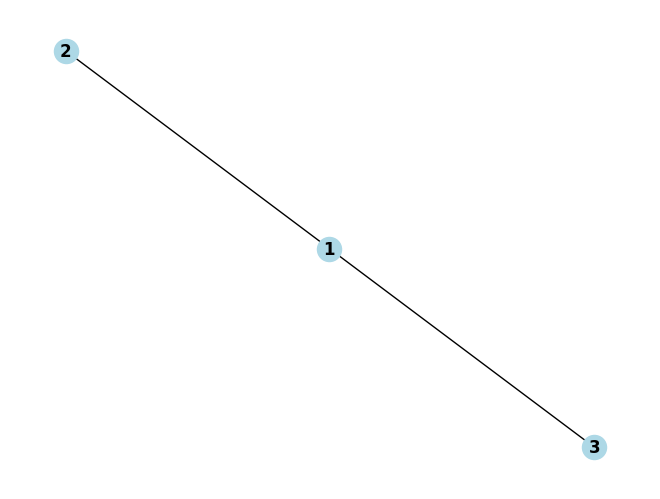

In [268]:
# Dibujar el grafo
nx.draw(G, with_labels=True, node_color='lightblue', font_weight='bold')
plt.show()

NetworkX tiene varios grafos clásicos incorporados para hacer pruebas. El grafo del "Club de Karate" es uno de los más famosos

Número de nodos: 34
Número de aristas: 78


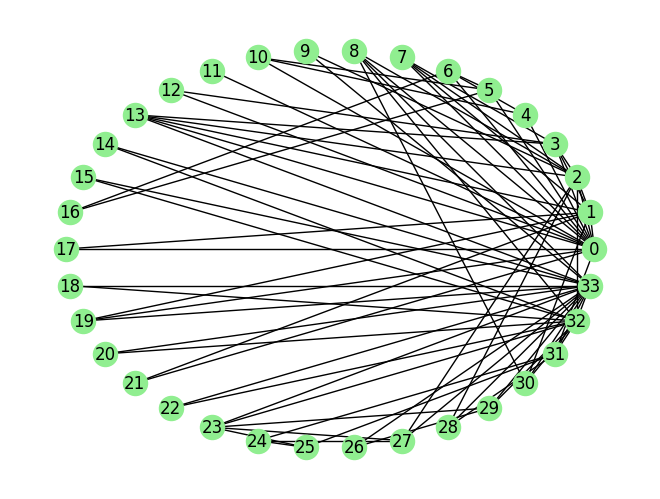

In [269]:
# Cargar el grafo del Club de Karate
G_karate = nx.karate_club_graph()

# Dibujar el grafo
print(f"Número de nodos: {G_karate.number_of_nodes()}")
print(f"Número de aristas: {G_karate.number_of_edges()}")
nx.draw_circular(G_karate, with_labels=True, node_color='lightgreen')
plt.show()

 **Realizar un Análisis Básico**
Puedes calcular métricas muy fácilmente. Por ejemplo, para ver el grado (número de conexiones) de un nodo específico :

In [270]:
# Calcular el grado del nodo 0 en el grafo del club de karate
grado_nodo_0 = G_karate.degree(0)
print(f"El grado del nodo 0 es: {grado_nodo_0}")

# Calcular el grado de todos los nodos
print("\nGrado de todos los nodos:")
for nodo, grado in G_karate.degree():
    print(f"  Nodo {nodo}: {grado}")

El grado del nodo 0 es: 16

Grado de todos los nodos:
  Nodo 0: 16
  Nodo 1: 9
  Nodo 2: 10
  Nodo 3: 6
  Nodo 4: 3
  Nodo 5: 4
  Nodo 6: 4
  Nodo 7: 4
  Nodo 8: 5
  Nodo 9: 2
  Nodo 10: 3
  Nodo 11: 1
  Nodo 12: 2
  Nodo 13: 5
  Nodo 14: 2
  Nodo 15: 2
  Nodo 16: 2
  Nodo 17: 2
  Nodo 18: 2
  Nodo 19: 3
  Nodo 20: 2
  Nodo 21: 2
  Nodo 22: 2
  Nodo 23: 5
  Nodo 24: 3
  Nodo 25: 3
  Nodo 26: 2
  Nodo 27: 4
  Nodo 28: 3
  Nodo 29: 4
  Nodo 30: 4
  Nodo 31: 6
  Nodo 32: 12
  Nodo 33: 17


**Bordes**
G también se puede aumentar añadiendo un borde a la vez.

In [271]:
G.add_edge(1, 2)
e = (2, 3)
G.add_edge(*e)  # desempaquetar tupla de borde*

añadiendo una lista de aristas:

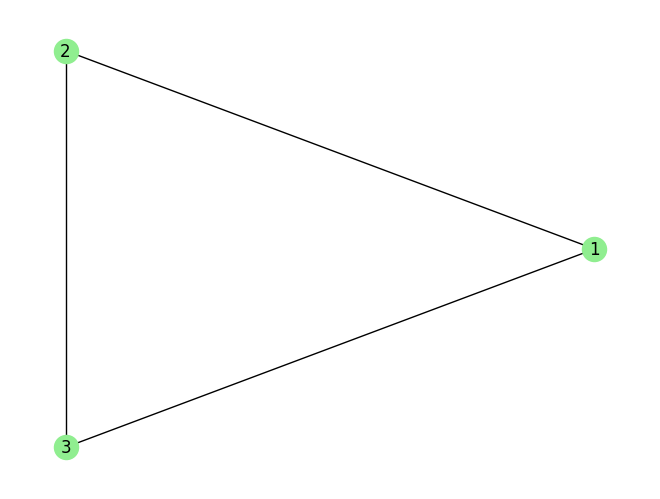

In [272]:
G.add_edges_from([(1, 2), (1, 3)])
nx.draw_circular(G, with_labels=True, node_color='lightgreen')
plt.show()

Añadimos nuevos nodos/bordes y NetworkX ignora silenciosamente los que ya están presentes.

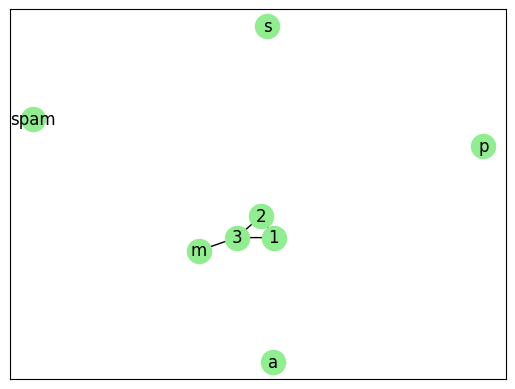

In [273]:
G.add_edges_from([(1, 2), (1, 3)])
G.add_node(1)
G.add_edge(1, 2)
G.add_node("spam")        # nodos"spam"
G.add_nodes_from("spam")  #  4 nodos: 's', 'p', 'a', 'm'
G.add_edge(3, 'm')
nx.draw_networkx(G, with_labels=True, node_color='lightgreen')


 <span style="color:purple;">**Tutorial: Diagramas de Transición con NetworkX**</span>

In [274]:
# Importar librerías
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

Crearemos algunos diagramas con distintos estilos de flechas para este entorno

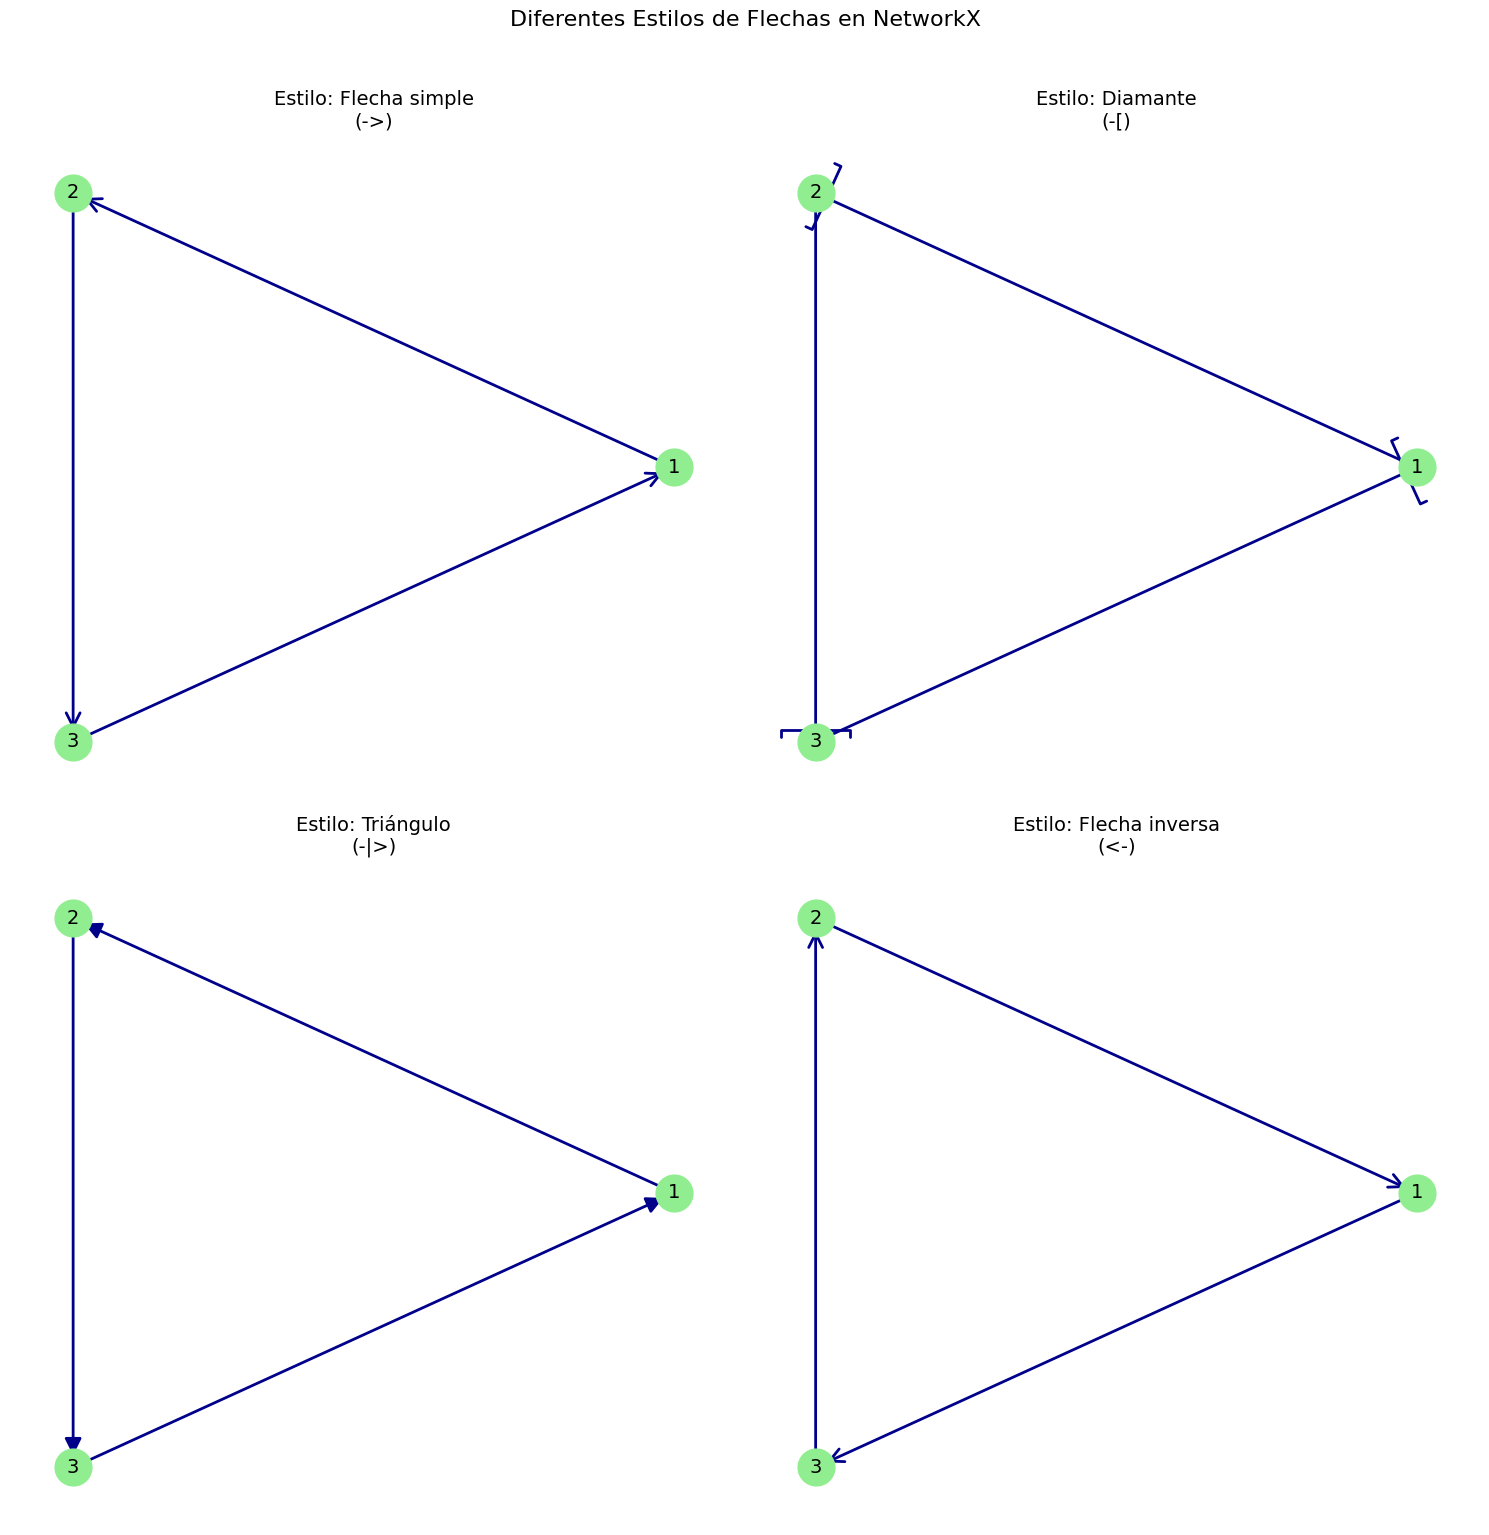

In [275]:
# Crear varios grafos para mostrar diferentes estilos
fig, axes = plt.subplots(2, 2, figsize=(15, 15))
estilos_flecha = ['->', '-[', '-|>', '<-']  # Diferentes estilos
nombres_estilo = ['Flecha simple', 'Diamante', 'Triángulo', 'Flecha inversa']
for ax, estilo, nombre in zip(axes.flat, estilos_flecha, nombres_estilo):
    # Crear grafo simple para cada ejemplo
    H = nx.DiGraph()
    H.add_edges_from([(1, 2), (2, 3), (3, 1)]) #Estados nodos en este caso
    pos_ej = nx.circular_layout(H)

    # Dibujar con diferentes estilos de flecha
    nx.draw_networkx_nodes(H, pos_ej, ax=ax, node_color='lightgreen', node_size=700) #Tamaño y grosor del nodo
    nx.draw_networkx_edges(H, pos_ej, ax=ax,
                          arrows=True,
                          arrowstyle=estilo,
                          arrowsize=25,
                          width=2,
                          edge_color='darkblue')
    nx.draw_networkx_labels(H, pos_ej, ax=ax, font_size=14)

    ax.set_title(f"Estilo: {nombre}\n({estilo})", fontsize=14)
    ax.axis('off')
plt.suptitle("Diferentes Estilos de Flechas en NetworkX", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

Supongamos las siguientes probabilidades para el diagrama de transición
$$
p=
\begin{bmatrix}
0.20 &  0.30 & 0.50\\
0.10 & 0.00 &0.90\\
0.55 &0.00 & 0.45
\end{bmatrix}
$$
o bien
$$
p=
\begin{bmatrix}
p_{1,1} &  p_{1,2}  & p_{1,3} \\
p_{2,1} &  p_{2,2}  & p_{2,3}\\
p_{3,1} &  p_{3,2}  & p_{3,3}
\end{bmatrix}
$$

In [276]:
# Crear un grafo dirigido
G = nx.DiGraph()

Definimos el diagrama de transición

In [277]:
# Definir la matriz de transición
P = [
    [0.20, 0.30, 0.50],  # Estado 1
    [0.10, 0.00, 0.90],  # Estado 2
    [0.55, 0.00, 0.45]   # Estado 3
]

Añadimos los nodos (estados 1, 2, 3)


In [278]:
G.add_nodes_from([1, 2, 3])

# Añadir aristas solo donde la probabilidad > 0
for i in range(3):
    for j in range(3):
        prob = P[i][j]
        if prob > 0:  # Solo crear arista si hay transición
            G.add_edge(i+1, j+1, weight=prob, label=f'{prob:.2f}')

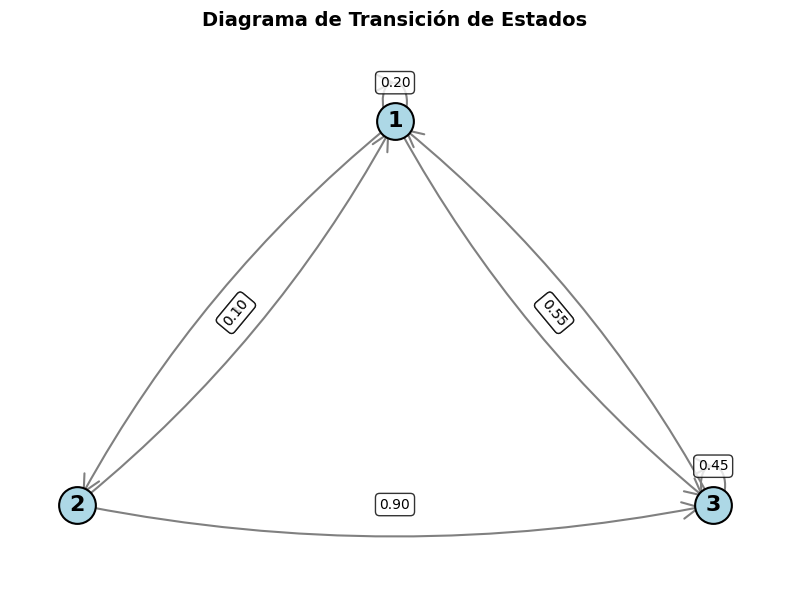

In [279]:
# Configurar la visualización
plt.figure(figsize=(8, 6))

# Posición de los nodos en triángulo
pos = {
    1: (0, 1),    # Estado 1 arriba
    2: (-1, 0),   # Estado 2 izquierda
    3: (1, 0)     # Estado 3 derecha
}
# Dibujar nodos
nx.draw_networkx_nodes(G, pos,
                      node_color='lightblue', #color del nodo
                      node_size=700, #tamaño del nodo
                      edgecolors='black', #color de borde
                      linewidths=1.5)

# Dibujar aristas con flechas simples ->
nx.draw_networkx_edges(G, pos,
                      arrows=True,
                      arrowstyle='->',
                      arrowsize=30, #grosor de la flecha
                      width=1.5,
                      edge_color='gray',
                      connectionstyle='arc3,rad=0.1')  # Curvatura suave para las flechas

# Etiquetas de los nodos
nx.draw_networkx_labels(G, pos,
                       labels={1: '1', 2: '2', 3: '3'},
                       font_size=16,
                       font_weight='bold')

# Etiquetas de las aristas (probabilidades)
edge_labels = {(u, v): d['label'] for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos,
                            edge_labels=edge_labels,
                            font_size=10,
                            bbox=dict(boxstyle='round,pad=0.3',
                                     facecolor='white',
                                     alpha=0.8))

plt.title('Diagrama de Transición de Estados', fontsize=14, fontweight='bold', pad=20)
plt.axis('off')
plt.tight_layout()
plt.show()


Otra forma mas sencilla

In [280]:
# Matriz de transición
P = [[0.20, 0.30, 0.50],
     [0.10, 0.00, 0.90],
     [0.55, 0.00, 0.45]]

Creación del gráfico

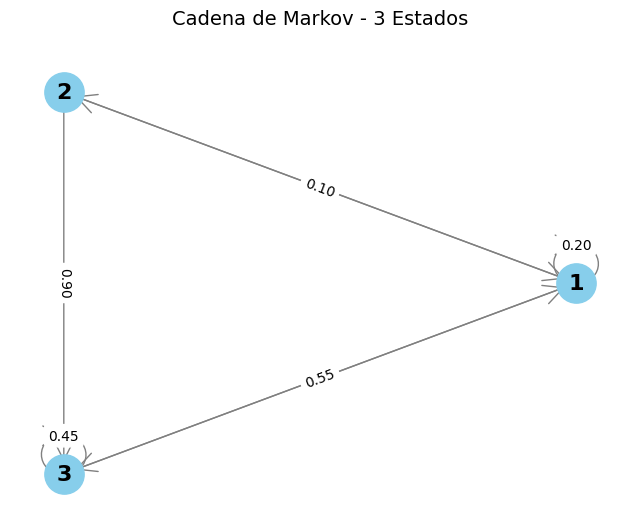

In [281]:
G = nx.DiGraph()
for i in range(3):
    for j in range(3):
        if P[i][j] > 0:
            G.add_edge(i+1, j+1, prob=P[i][j])

# Visualizar
plt.figure(figsize=(8, 6))
pos = nx.circular_layout(G)

nx.draw_networkx_nodes(G, pos, node_color='skyblue', node_size=800)
nx.draw_networkx_edges(G, pos, arrows=True, arrowstyle='->',
                      arrowsize=35, edge_color='gray')
nx.draw_networkx_labels(G, pos, font_size=16, font_weight='bold')

edge_labels = {(i+1, j+1): f'{P[i][j]:.2f}'
               for i in range(3) for j in range(3) if P[i][j] > 0}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=10)

plt.title('Cadena de Markov - 3 Estados', fontsize=14, pad=20)
plt.axis('off')
plt.show()